In [2]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import sys
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [3]:
from src.utils.visualization_utils import (
    save_fig, 
    highlight_max_bar, 
    set_labels
    )

In [4]:
BASE_PATH = os.getenv("BASE_PATH")
df = pd.read_parquet(f"{BASE_PATH}/data/processed/clean_delivery_time.parquet")
df.head()

,Distance_m,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7930.0,Windy,Low,Afternoon,Scooter,12,1,43
1,16420.0,Clear,Medium,Evening,Bike,20,2,84
2,9520.0,Foggy,Low,Night,Scooter,28,1,59
3,7440.0,Rainy,Medium,Afternoon,Scooter,5,1,37
4,19030.0,Clear,Low,Morning,Bike,16,5,68


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Distance_m              1000 non-null   float64 
 1   Weather                 1000 non-null   category
 2   Traffic_Level           1000 non-null   category
 3   Time_of_Day             1000 non-null   category
 4   Vehicle_Type            1000 non-null   category
 5   Preparation_Time_min    1000 non-null   uint8   
 6   Courier_Experience_yrs  1000 non-null   uint8   
 7   Delivery_Time_min       1000 non-null   uint8   
dtypes: category(4), float64(1), uint8(3)
memory usage: 15.0 KB


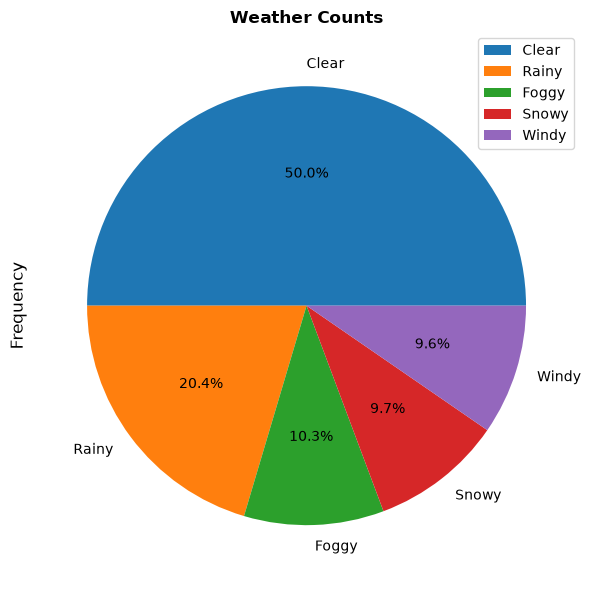

In [7]:
weather_counts = df['Weather'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(
    x=weather_counts,
    labels=weather_counts.index, # type: ignore
    autopct='%1.1f%%',
)
set_labels(title='Weather Counts')
plt.tight_layout()
plt.legend()
plt.show()

### Observations:
- Nearly half of all orders were placed during Clear weather conditions.
- Approximately one in five orders occurred during Rainy weather.
- About one in ten orders were placed during Foggy weather.
- Snowy and Windy weather accounted for nearly identical shares, at approximately 9.7% each.

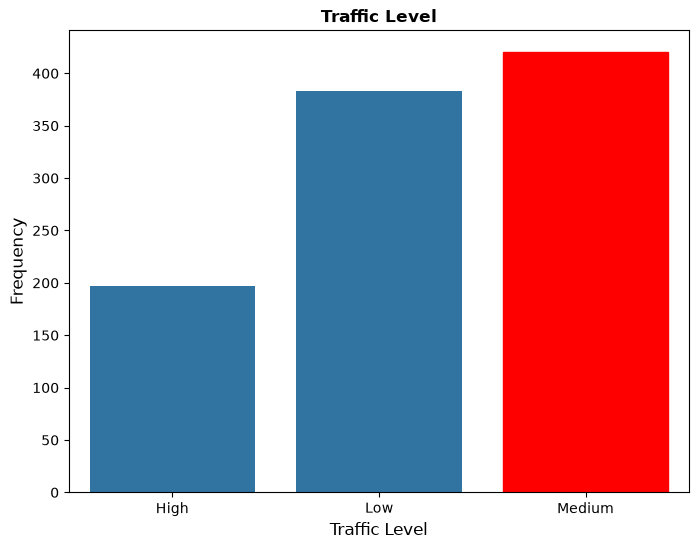

In [16]:
traffic_level_counts = df['Traffic_Level'].value_counts()
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(
        x=traffic_level_counts.index,
         y=traffic_level_counts.values )
set_labels(title="Traffic Level", xlabel='Traffic Level', ylabel="Frequency")
highlight_max_bar(ax)
plt.show()

### Observations:
- About **40% of all orders** were placed under **Medium** traffic conditions.
- Approximately **36% of orders** occurred during **Low** traffic conditions.
- Roughly **one in five orders** were placed during **High** traffic conditions.

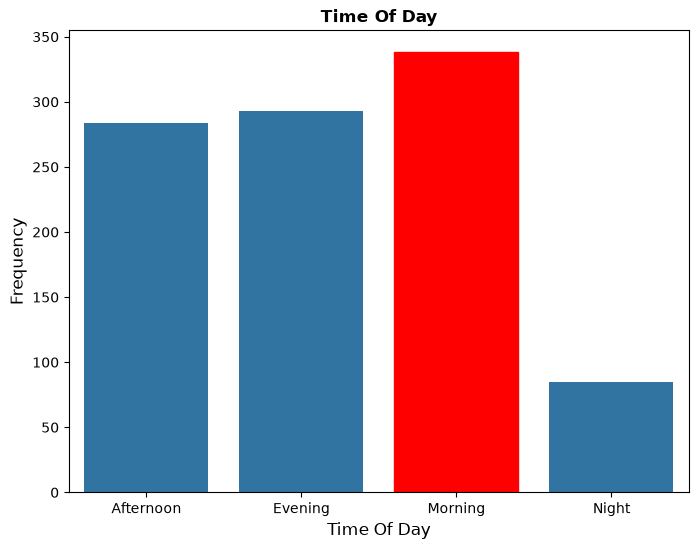

In [18]:
time_day_counts = df['Time_of_Day'].value_counts()
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(
        x=time_day_counts.index,
         y=time_day_counts.values )
set_labels(title="Time of Day", xlabel='Time of Day', ylabel="Frequency")
highlight_max_bar(ax)
plt.show()

### Observations:
- Approximately **one in three orders** were placed during the **Morning**.
- **Afternoon** and **Evening** had **almost identical order volumes**, with approximately **275 orders** each.
- Only **about 8% of orders** were placed during the **Night**.

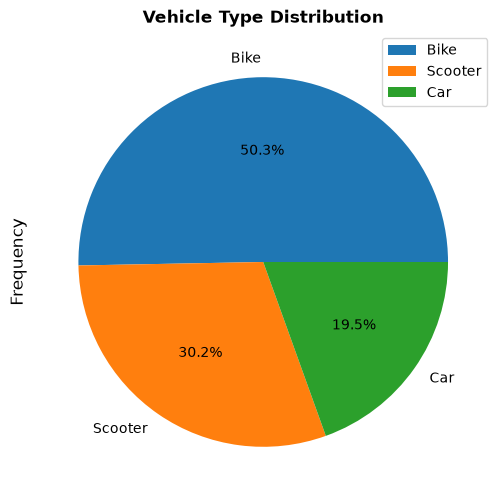

In [22]:
vehicle_types_counts = df['Vehicle_Type'].value_counts()
fig, ax = plt.subplots(figsize=(8,6))
plt.pie(
    x=vehicle_types_counts.values, #type: ignore
    labels=vehicle_types_counts.index, #type: ignore
    autopct='%1.1f%%',
)
set_labels("Vehicle Type Distribution")
plt.legend()
plt.show()

### Observations:
- Approximately **50.03% of all orders** were delivered by **Bike**.
- Around **30.2% of orders** were delivered by **Scooter**.
- The remaining **19.5% of orders** were delivered by **Car**.

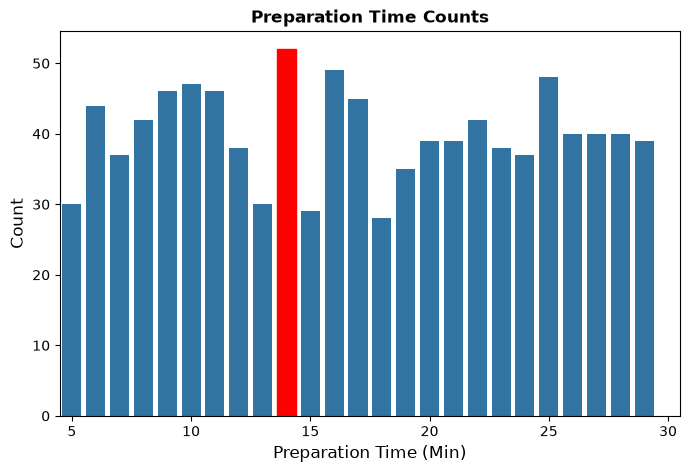

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Preparation_Time_min",
    ax=ax
)

ax.set_xlim(-0.5, 25.5)   
ax.set_xticks(range(0, 26, 5))  
ax.set_xticklabels(range(5, 31, 5)) # type: ignore
highlight_max_bar(ax)
set_labels("Preparation Time Counts", "Preparation Time (Min)","Count")

plt.show()

### Observations:
- **Preparation times are fairly evenly distributed** across the range of **5 to 29 minutes**, with no strong concentration at a specific duration.
- The **highest number of orders** occurred at a **preparation time of 14 minutes** (highlighted in red), with approximately **52 orders**.
- Most preparation times recorded **between 35 and 50 orders**, indicating a relatively balanced distribution.
- Preparation times of **15 and 18 minutes** had the **lowest order counts**, with fewer than **30 orders** each.

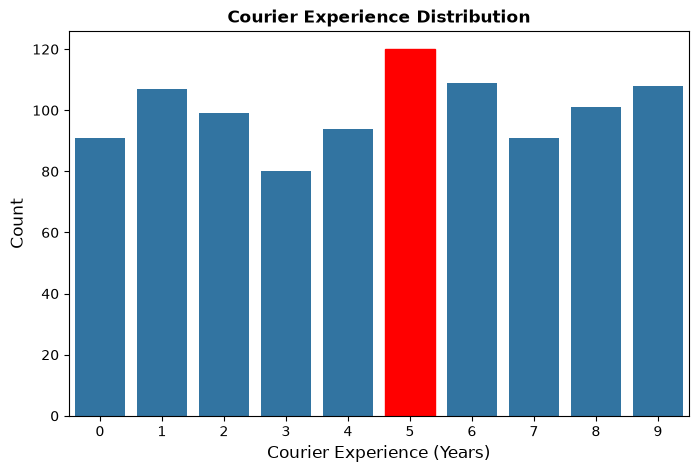

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Courier_Experience_yrs",
    ax=ax
)

highlight_max_bar(ax)
set_labels(
    "Courier Experience Distribution",
    "Courier Experience (Years)",
    "Count"
)

plt.show()

### Observations:
- The **highest number of orders** was handled by couriers with **5 years of experience**, with approximately **120 orders**.
- Order counts are **fairly evenly distributed** across all experience levels, indicating no strong dependence on courier experience.
- Couriers with **3 years of experience** handled the **fewest orders**, with around **80 orders**.
- Most experience levels accounted for **90 to 110 orders**, suggesting a balanced allocation of deliveries among couriers.